# Data Modelling

## Load Library

In [2]:
# configuration
RANDOM_STATE = 0
TARGET_SIZE = (128, 128)  # Consistent dengan Data Splitting
BATCH_SIZE = 32
EPOCHS = 50
PATIENCE = 10  # Early stopping patience

In [3]:
# hyperparameters untuk tunning
LEARNING_RATES = [0.001, 0.0001, 0.00001]  # Learning rate candidates
DROPOUT_RATES = [0.3, 0.5, 0.7]  # Dropout candidates
DENSE_UNITS = [256, 512, 1024]  # Dense layer units candidates

In [4]:
# load library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle
from pathlib import Path

In [5]:
# tensorflow & keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten, BatchNormalization,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.applications import VGG16, VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau,
    CSVLogger, TensorBoard
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras import regularizers

2025-10-23 23:18:29.143808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761261509.341708      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761261509.396222      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# metrics
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
# progress tracking
from tqdm import tqdm
import time
import datetime

In [8]:
# set seeds for reproducibility
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [9]:
# styling and configuration gpu

# GPU configuration (jika available)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ Libraries loaded successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {keras.__version__}")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
✓ Libraries loaded successfully!
TensorFlow version: 2.18.0
Keras version: 3.8.0


In [10]:
# load data splitting checkpoint

# path to location
SPLIT_OUTPUT = '/kaggle/input/data-splitting-face-recognition/'
IMAGE_PATH = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

# load split dataframes
train_df = pd.read_csv(f'{SPLIT_OUTPUT}train_split.csv')
val_df = pd.read_csv(f'{SPLIT_OUTPUT}val_split.csv')
test_df = pd.read_csv(f'{SPLIT_OUTPUT}test_split.csv')

print(f"✓ Train set: {len(train_df)} images")
print(f"✓ Val set:   {len(val_df)} images")
print(f"✓ Test set:  {len(test_df)} images")

# load metadata
with open(f'{SPLIT_OUTPUT}split_metadata.pkl', 'rb') as f:
    split_metadata = pickle.load(f)

with open(f'{SPLIT_OUTPUT}generator_config.pkl', 'rb') as f:
    gen_config = pickle.load(f)

print("\n" + "="*50)
print("SPLIT METADATA")
print("="*50)
print(f"Target size: {split_metadata['target_size']}")
print(f"Batch size: {split_metadata['batch_size']}")
print(f"Class indices: {split_metadata['class_indices']}")

# update configuration dari checkpoint
TARGET_SIZE = split_metadata['target_size']
BATCH_SIZE = split_metadata['batch_size']

✓ Train set: 118207 images
✓ Val set:   25330 images
✓ Test set:  25331 images

SPLIT METADATA
Target size: (128, 128)
Batch size: 32
Class indices: {'0': 0, '1': 1}


In [12]:
# convert lable to string
# Keras ImageDataGenerator flow_from_dataframe butuh string untuk binary classification

# check tipe data label
print("\n" + "="*50)
print("CHECKING LABEL DATA TYPE")
print("="*50)
print(f"Train label dtype: {train_df['label'].dtype}")
print(f"Sample labels: {train_df['label'].head().tolist()}")

# convert label ke string jika belum
if train_df['label'].dtype != 'object':
    train_df['label'] = train_df['label'].astype(str)
    val_df['label'] = val_df['label'].astype(str)
    test_df['label'] = test_df['label'].astype(str)
    print("\n✓ Converted labels to string")
else:
    print("\n✓ Labels already in string format")

print(f"Train label dtype after conversion: {train_df['label'].dtype}")
print(f"Sample labels: {train_df['label'].head().tolist()}")

# verify unique labels
print(f"\nUnique labels in train: {train_df['label'].unique()}")
print(f"Label distribution:\n{train_df['label'].value_counts()}")



CHECKING LABEL DATA TYPE
Train label dtype: int64
Sample labels: [0, 0, 1, 0, 1]

✓ Converted labels to string
Train label dtype after conversion: object
Sample labels: ['0', '0', '1', '0', '1']

Unique labels in train: ['0' '1']
Label distribution:
label
1    59104
0    59103
Name: count, dtype: int64


In [13]:
# recreate data generators

# train generator dengan augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# validation & test generator (hanya rescale)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# create generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True,
    seed=RANDOM_STATE
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepath',
    y_col='label',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("\n✓ Generators recreated successfully!")
print(f"Train batches: {len(train_generator)}")
print(f"Val batches:   {len(val_generator)}")
print(f"Test batches:  {len(test_generator)}")

Found 118207 validated image filenames belonging to 2 classes.
Found 25330 validated image filenames belonging to 2 classes.
Found 25331 validated image filenames belonging to 2 classes.

✓ Generators recreated successfully!
Train batches: 3694
Val batches:   792
Test batches:  792



TESTING GENERATOR OUTPUT
Batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Pixel range: [0.000, 1.000]
Sample labels: [0. 0. 0. 0. 1. 0. 1. 1. 0. 1.]


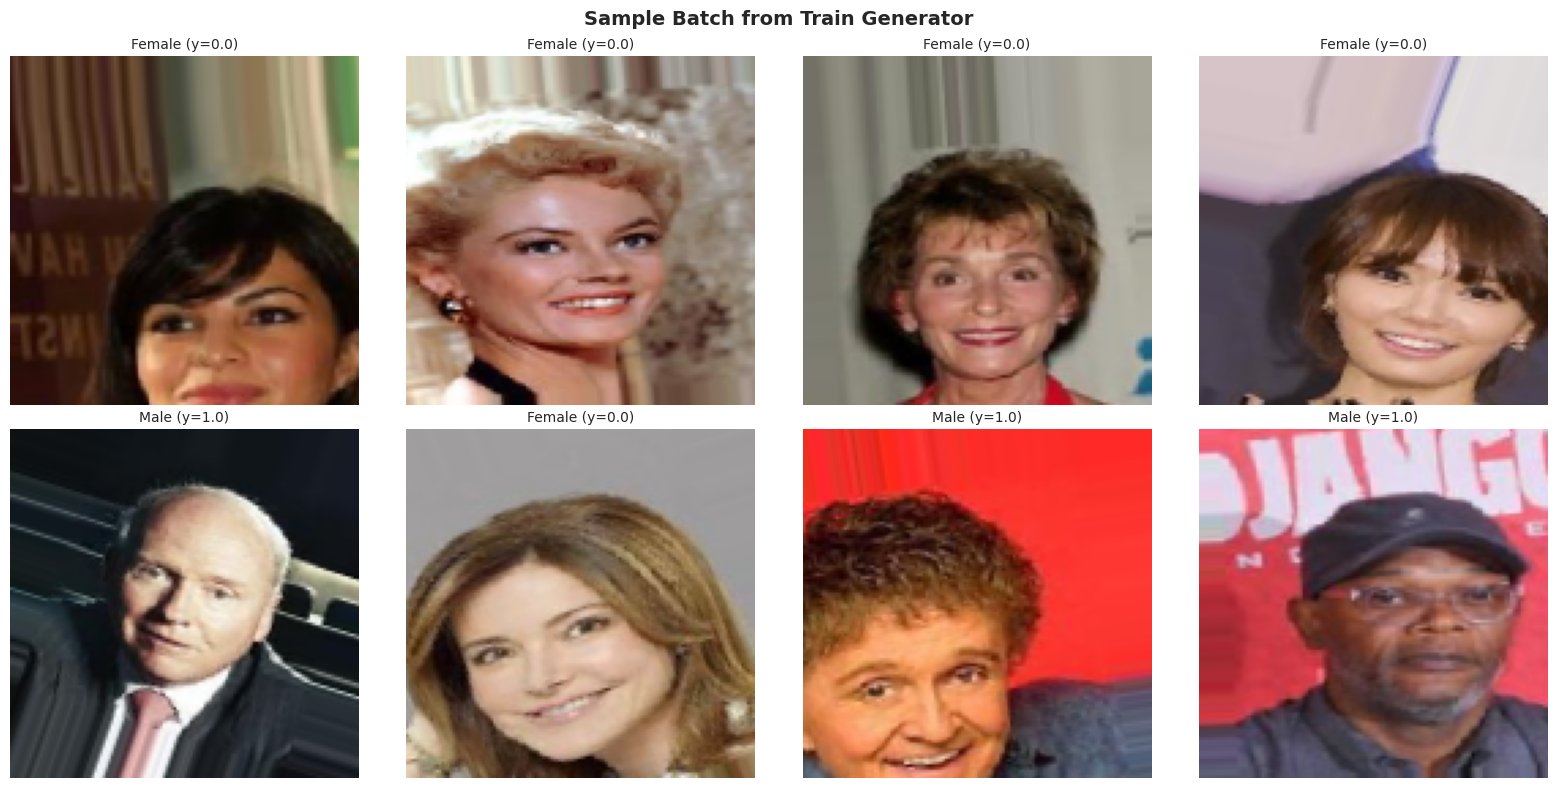


✓ Generator working correctly!


In [15]:
print("\n" + "="*50)
print("TESTING GENERATOR OUTPUT")
print("="*50)

# get 1 batch
X_batch, y_batch = next(train_generator)

print(f"Batch shape: {X_batch.shape}")
print(f"Labels shape: {y_batch.shape}")
print(f"Pixel range: [{X_batch.min():.3f}, {X_batch.max():.3f}]")
print(f"Sample labels: {y_batch[:10]}")

# visualize batch
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i in range(8):
    axes[i].imshow(X_batch[i])
    label_text = 'Male' if y_batch[i] == 1 else 'Female'
    axes[i].set_title(f'{label_text} (y={y_batch[i]})', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Sample Batch from Train Generator', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Generator working correctly!")

## Data Modelling and Training

In [16]:
# create vgg model

def create_vgg_model(
    vgg_version='VGG16',  # 'VGG16' or 'VGG19'
    input_shape=(128, 128, 3),
    dense_units=512,
    dropout_rate=0.5,
    learning_rate=0.0001,
    trainable_base=False  # Freeze base layers
):
    """
    Create VGG-based model untuk binary classification (Gender)
    
    Args:
        vgg_version: 'VGG16' or 'VGG19'
        input_shape: Input image shape
        dense_units: Number of units di fully connected layer
        dropout_rate: Dropout rate
        learning_rate: Learning rate untuk optimizer
        trainable_base: Freeze/unfreeze VGG base layers
    
    Returns:
        Compiled Keras model
    """
    
    # load pre-trained VGG base
    if vgg_version == 'VGG16':
        base_model = VGG16(
            weights='imagenet',
            include_top=False,  # Exclude fully connected layers
            input_shape=input_shape
        )
    elif vgg_version == 'VGG19':
        base_model = VGG19(
            weights='imagenet',
            include_top=False,
            input_shape=input_shape
        )
    else:
        raise ValueError("vgg_version must be 'VGG16' or 'VGG19'")
    
    # freeze base layers (Transfer Learning)
    base_model.trainable = trainable_base
    
    print(f"\n{'='*50}")
    print(f"VGG BASE MODEL: {vgg_version}")
    print(f"{'='*50}")
    print(f"Total layers: {len(base_model.layers)}")
    print(f"Trainable: {trainable_base}")
    print(f"Base output shape: {base_model.output_shape}")
    
    return base_model

# test create base model
vgg_base = create_vgg_model(vgg_version='VGG16', trainable_base=False)
print("\n✓ VGG base model created successfully!")

I0000 00:00:1761262264.587559      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1761262264.588333      37 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

VGG BASE MODEL: VGG16
Total layers: 19
Trainable: False
Base output shape: (None, 4, 4, 512)

✓ VGG base model created successfully!


## Create Fully Layer Architecture

In [17]:
# build complete model with fc layers

def build_complete_model(
    vgg_version='VGG16',
    input_shape=(128, 128, 3),
    dense_units=512,
    dropout_rate=0.5,
    learning_rate=0.0001,
    l2_reg=0.001  # L2 regularization
):
    """
    Build complete model: VGG base + Fully Connected layers
    """
    
    # get VGG base
    base_model = create_vgg_model(
        vgg_version=vgg_version,
        input_shape=input_shape,
        trainable_base=False
    )
    
    # build Fully Connected layers
    model = Sequential([
        # VGG Base
        base_model,
        
        # flatten or Global Average Pooling
        # globalAveragePooling2D(),  # Alternative: lebih efisien
        Flatten(),
        
        # FC Layer 1
        Dense(
            dense_units,
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg),
            name='fc1'
        ),
        BatchNormalization(name='bn1'),
        Dropout(dropout_rate, name='dropout1'),
        
        # FC Layer 2 (Optional, bisa comment jika ingin lebih simple)
        Dense(
            dense_units // 2,  # Half of dense_units
            activation='relu',
            kernel_regularizer=regularizers.l2(l2_reg),
            name='fc2'
        ),
        BatchNormalization(name='bn2'),
        Dropout(dropout_rate, name='dropout2'),
        
        # output layer (Binary Classification)
        Dense(1, activation='sigmoid', name='output')
    ], name=f'{vgg_version}_Gender_Classifier')
    
    print(f"\n{'='*50}")
    print(f"FULLY CONNECTED ARCHITECTURE")
    print(f"{'='*50}")
    print(f"Dense units: {dense_units}")
    print(f"Dropout rate: {dropout_rate}")
    print(f"L2 regularization: {l2_reg}")
    
    return model

# test build complete model
test_model = build_complete_model(
    vgg_version='VGG16',
    dense_units=512,
    dropout_rate=0.5
)

print("\n" + "="*50)
print("MODEL SUMMARY")
print("="*50)
test_model.summary()

# count parameters
total_params = test_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in test_model.trainable_weights])
non_trainable_params = total_params - trainable_params

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Non-trainable parameters: {non_trainable_params:,}")


VGG BASE MODEL: VGG16
Total layers: 19
Trainable: False
Base output shape: (None, 4, 4, 512)

FULLY CONNECTED ARCHITECTURE
Dense units: 512
Dropout rate: 0.5
L2 regularization: 0.001

MODEL SUMMARY


Model: "VGG16_Gender_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,044,161 (72.65 MB)

 Trainable params: 4,327,937 (16.51 MB)

 Non-trainable params: 14,716,224 (56.14 MB)


Total parameters: 19,044,161
Trainable parameters: 4,327,937
Non-trainable parameters: 14,716,224


## Compile Model and Hyperparameter tuning

In [18]:
# compile model

def compile_model(model, learning_rate=0.0001, optimizer_type='adam'):
    """
    Compile model dengan optimizer, loss, dan metrics
    """
    
    # Choose optimizer
    if optimizer_type.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_type.lower() == 'sgd':
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        raise ValueError("optimizer_type must be 'adam' or 'sgd'")
    
    # Compile
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',  # Binary classification
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )
    
    print(f"\n✓ Model compiled with {optimizer_type.upper()} optimizer")
    print(f"  Learning rate: {learning_rate}")
    print(f"  Loss: binary_crossentropy")
    print(f"  Metrics: accuracy, precision, recall, auc")
    
    return model

In [19]:
# hyperparameter tuning setup

print("\n" + "="*50)
print("HYPERPARAMETER TUNING CONFIGURATION")
print("="*50)

# Define hyperparameter grid
hyperparam_grid = {
    'vgg_version': ['VGG16'],  # Bisa tambah 'VGG19' jika mau
    'dense_units': DENSE_UNITS,  # [256, 512, 1024]
    'dropout_rate': DROPOUT_RATES,  # [0.3, 0.5, 0.7]
    'learning_rate': LEARNING_RATES  # [0.001, 0.0001, 0.00001]
}

# Calculate total combinations
total_combinations = 1
for key, values in hyperparam_grid.items():
    total_combinations *= len(values)

print(f"\nHyperparameter grid:")
for key, values in hyperparam_grid.items():
    print(f"  {key}: {values}")

print(f"\nTotal combinations: {total_combinations}")
print(f"Estimated time: ~{total_combinations * 20} minutes (jika ~20 min per model)")


HYPERPARAMETER TUNING CONFIGURATION

Hyperparameter grid:
  vgg_version: ['VGG16']
  dense_units: [256, 512, 1024]
  dropout_rate: [0.3, 0.5, 0.7]
  learning_rate: [0.001, 0.0001, 1e-05]

Total combinations: 27
Estimated time: ~540 minutes (jika ~20 min per model)


In [20]:
# ============================================
# STRATEGI HYPERPARAMETER TUNING
# ============================================

print("\n" + "="*50)
print("TUNING STRATEGY")
print("="*50)

# Pilihan 1: GRID SEARCH (Exhaustive - lambat tapi thorough)
# Mencoba SEMUA kombinasi hyperparameter

# Pilihan 2: RANDOM SEARCH (Cepat - sample random combinations)
# Hanya sample beberapa kombinasi random

# Pilihan 3: MANUAL TUNING (Paling cepat untuk demo/assignment)
# Pilih 2-3 kombinasi terbaik berdasarkan intuisi

print("""
Pilihan strategi:
1. Grid Search: Coba semua kombinasi (lambat, thorough)
2. Random Search: Coba beberapa kombinasi random (sedang)
3. Manual Tuning: Coba 2-3 kombinasi terbaik (cepat)

Untuk assignment/demo, saya rekomendasikan Manual Tuning
dengan 3 konfigurasi:
  - Baseline: dense=512, dropout=0.5, lr=0.0001
  - High capacity: dense=1024, dropout=0.3, lr=0.0001
  - Regularized: dense=512, dropout=0.7, lr=0.00001
""")

# ============================================
# MANUAL TUNING: DEFINE 3 BEST CONFIGURATIONS
# ============================================

tuning_configs = [
    {
        'name': 'Baseline',
        'vgg_version': 'VGG16',
        'dense_units': 512,
        'dropout_rate': 0.5,
        'learning_rate': 0.0001
    },
    {
        'name': 'High_Capacity',
        'vgg_version': 'VGG16',
        'dense_units': 1024,
        'dropout_rate': 0.3,
        'learning_rate': 0.0001
    },
    {
        'name': 'Regularized',
        'vgg_version': 'VGG16',
        'dense_units': 512,
        'dropout_rate': 0.7,
        'learning_rate': 0.00001
    }
]

print("\n" + "="*50)
print("SELECTED CONFIGURATIONS FOR TUNING")
print("="*50)
for i, config in enumerate(tuning_configs, 1):
    print(f"\nConfig {i}: {config['name']}")
    for key, value in config.items():
        if key != 'name':
            print(f"  {key}: {value}")


TUNING STRATEGY

Pilihan strategi:
1. Grid Search: Coba semua kombinasi (lambat, thorough)
2. Random Search: Coba beberapa kombinasi random (sedang)
3. Manual Tuning: Coba 2-3 kombinasi terbaik (cepat)

Untuk assignment/demo, saya rekomendasikan Manual Tuning
dengan 3 konfigurasi:
  - Baseline: dense=512, dropout=0.5, lr=0.0001
  - High capacity: dense=1024, dropout=0.3, lr=0.0001
  - Regularized: dense=512, dropout=0.7, lr=0.00001


SELECTED CONFIGURATIONS FOR TUNING

Config 1: Baseline
  vgg_version: VGG16
  dense_units: 512
  dropout_rate: 0.5
  learning_rate: 0.0001

Config 2: High_Capacity
  vgg_version: VGG16
  dense_units: 1024
  dropout_rate: 0.3
  learning_rate: 0.0001

Config 3: Regularized
  vgg_version: VGG16
  dense_units: 512
  dropout_rate: 0.7
  learning_rate: 1e-05


## Model Training

In [21]:
# train model with callbacks

def train_model(
    model,
    train_gen,
    val_gen,
    epochs=50,
    model_name='model',
    patience=10
):
    """
    Train model dengan callbacks
    """
    
    # Define callbacks
    callbacks = [
        # Early Stopping
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        ),
        
        # Model Checkpoint
        ModelCheckpoint(
            filepath=f'/kaggle/working/{model_name}_best.h5',
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        
        # Reduce Learning Rate on Plateau
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,  # Reduce LR by half
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # CSV Logger
        CSVLogger(
            filename=f'/kaggle/working/{model_name}_training_log.csv'
        )
    ]
    
    print(f"\n{'='*50}")
    print(f"TRAINING: {model_name}")
    print(f"{'='*50}")
    print(f"Epochs: {epochs}")
    print(f"Patience: {patience}")
    print(f"Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger")
    
    # Training
    start_time = time.time()
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    elapsed_time = time.time() - start_time
    
    print(f"\n✓ Training completed in {elapsed_time/60:.2f} minutes")
    
    return history, elapsed_time

In [25]:
# hyperparameter tuning loop

# dictionary untuk menyimpan hasil semua model
tuning_results = {}

print("\n" + "="*70)
print("STARTING HYPERPARAMETER TUNING")
print("="*70)

for i, config in enumerate(tuning_configs, 1):
    print(f"\n{'#'*70}")
    print(f"# TRAINING MODEL {i}/{len(tuning_configs)}: {config['name']}")
    print(f"{'#'*70}")
    
    # Build model
    model = build_complete_model(
        vgg_version=config['vgg_version'],
        input_shape=(*TARGET_SIZE, 3),
        dense_units=config['dense_units'],
        dropout_rate=config['dropout_rate'],
        learning_rate=config['learning_rate']
    )
    
    # Compile model
    model = compile_model(
        model,
        learning_rate=config['learning_rate']
    )
    
    # Train model
    history, train_time = train_model(
        model=model,
        train_gen=train_generator,
        val_gen=val_generator,
        # epochs=EPOCHS,
        epochs=2,
        model_name=config['name'],
        patience=PATIENCE
    )
    
    # Evaluate on validation set
    val_results = model.evaluate(val_generator, verbose=0)
    
    # Store results
    tuning_results[config['name']] = {
        'config': config,
        'history': history.history,
        'val_loss': val_results[0],
        'val_accuracy': val_results[1],
        'val_precision': val_results[2],
        'val_recall': val_results[3],
        'val_auc': val_results[4],
        'training_time': train_time,
        'model': model
    }
    
    print(f"\n{'='*50}")
    print(f"RESULTS: {config['name']}")
    print(f"{'='*50}")
    print(f"Val Loss: {val_results[0]:.4f}")
    print(f"Val Accuracy: {val_results[1]:.4f}")
    print(f"Val Precision: {val_results[2]:.4f}")
    print(f"Val Recall: {val_results[3]:.4f}")
    print(f"Val AUC: {val_results[4]:.4f}")
    print(f"Training Time: {train_time/60:.2f} minutes")
    
    # Clear session untuk free memory
    tf.keras.backend.clear_session()

print("\n" + "="*70)
print("HYPERPARAMETER TUNING COMPLETED!")
print("="*70)


STARTING HYPERPARAMETER TUNING

######################################################################
# TRAINING MODEL 1/3: Baseline
######################################################################

VGG BASE MODEL: VGG16
Total layers: 19
Trainable: False
Base output shape: (None, 4, 4, 512)

FULLY CONNECTED ARCHITECTURE
Dense units: 512
Dropout rate: 0.5
L2 regularization: 0.001

✓ Model compiled with ADAM optimizer
  Learning rate: 0.0001
  Loss: binary_crossentropy
  Metrics: accuracy, precision, recall, auc

TRAINING: Baseline
Epochs: 2
Patience: 10
Callbacks: EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger
Epoch 1/2
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.8204 - auc: 0.8997 - loss: 1.3707 - precision: 0.8153 - recall: 0.8293
Epoch 1: val_accuracy improved from -inf to 0.91145, saving model to /kaggle/working/Baseline_best.h5
3694/3694 ━━━━━━━━━━━━━━━━━━━━ 698s 187ms/step - accuracy: 0.8204 - auc: 0.8997 - loss: 1.3707 - precision: 0.8153 - re

## Validation Curves

In [29]:
# compare all models

print("\n" + "="*70)
print("MODEL COMPARISON SUMMARY")
print("="*70)

# create comparison dataframe
comparison_data = []
for model_name, results in tuning_results.items():
    comparison_data.append({
        'Model': model_name,
        'Val Accuracy': results['val_accuracy'],
        'Val Loss': results['val_loss'],
        'Val Precision': results['val_precision'],
        'Val Recall': results['val_recall'],
        'Val AUC': results['val_auc'],
        'Training Time (min)': results['training_time'] / 60,
        'Dense Units': results['config']['dense_units'],
        'Dropout': results['config']['dropout_rate'],
        'Learning Rate': results['config']['learning_rate']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Val Accuracy', ascending=False)

print("\n", comparison_df.to_string(index=False))

# find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model_results = tuning_results[best_model_name]

print(f"\n{'='*50}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*50}")
print(f"Val Accuracy: {best_model_results['val_accuracy']:.4f}")
print(f"Configuration:")
for key, value in best_model_results['config'].items():
    if key != 'name':
        print(f"  {key}: {value}")


MODEL COMPARISON SUMMARY

         Model  Val Accuracy  Val Loss  Val Precision  Val Recall  Val AUC  Training Time (min)  Dense Units  Dropout  Learning Rate
High_Capacity      0.921003  0.507140       0.912502    0.931307 0.976854            22.647846         1024      0.3        0.00010
     Baseline      0.903987  0.493265       0.859835    0.965338 0.974907            22.964543          512      0.5        0.00010
  Regularized      0.900355  1.309290       0.901242    0.899250 0.962059            21.742981          512      0.7        0.00001

BEST MODEL: High_Capacity
Val Accuracy: 0.9210
Configuration:
  vgg_version: VGG16
  dense_units: 1024
  dropout_rate: 0.3
  learning_rate: 0.0001



Plotting curves for: Baseline


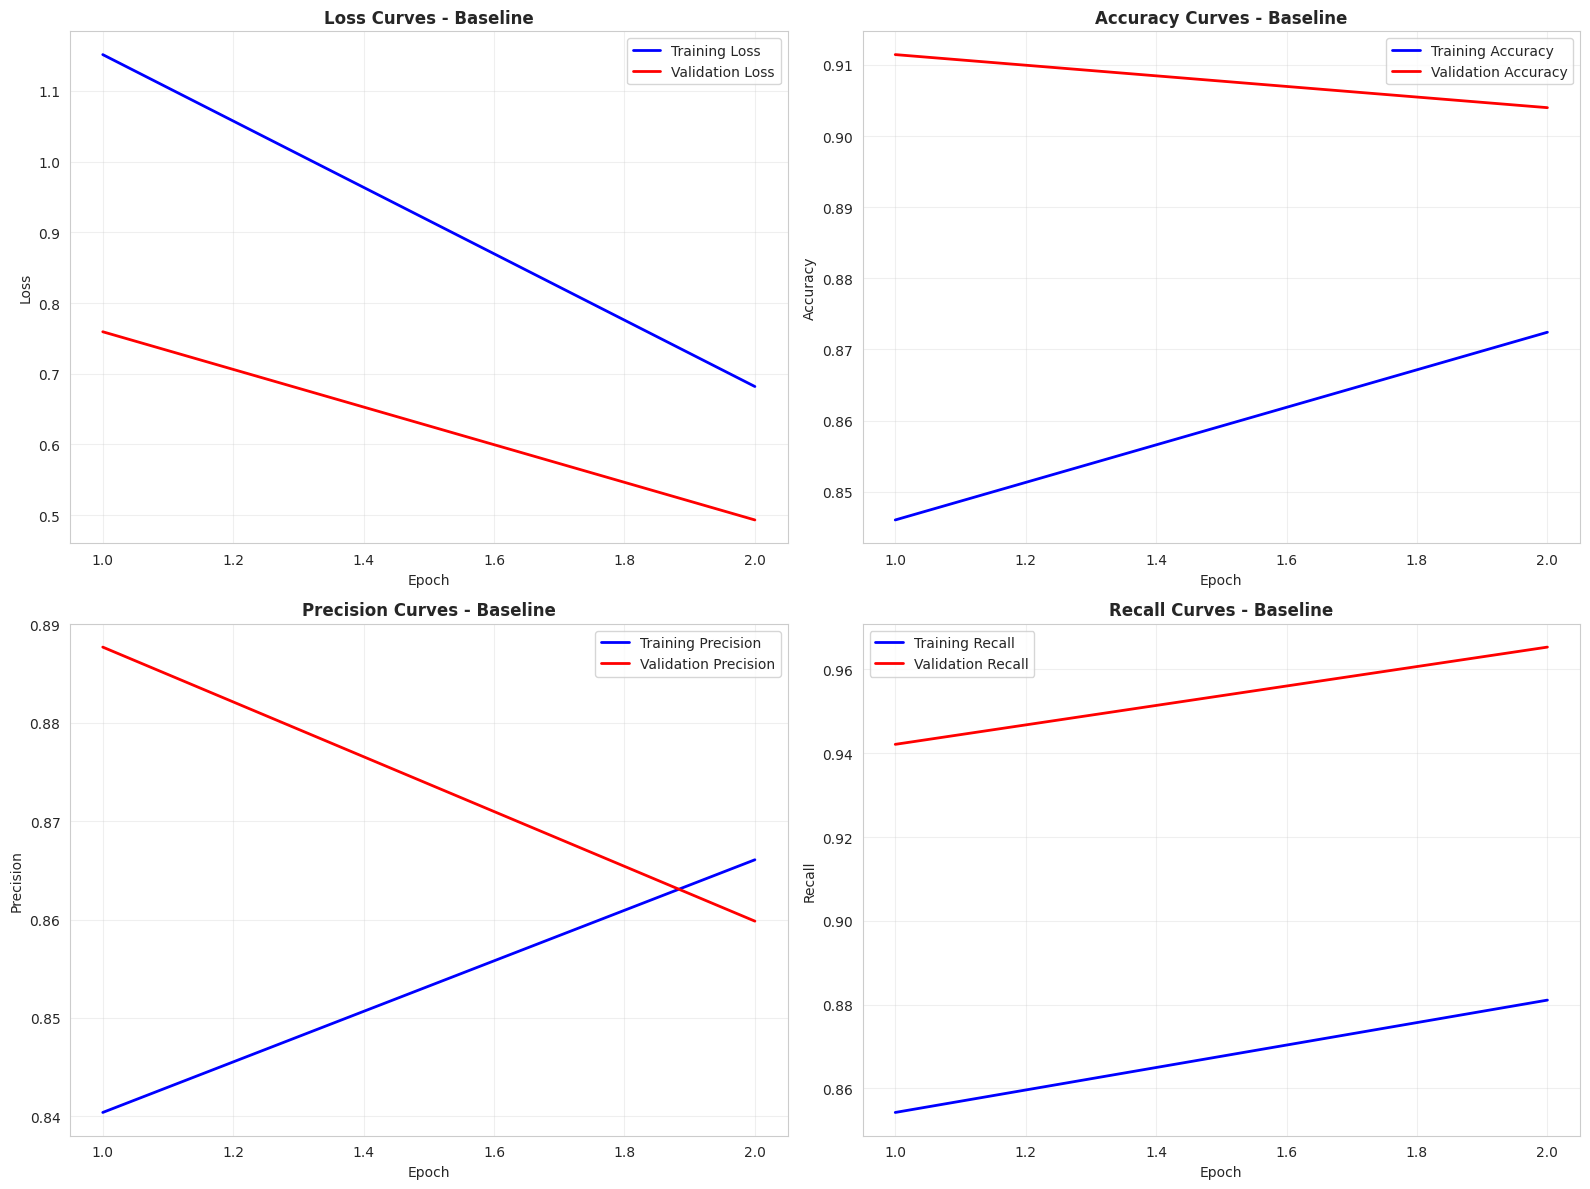


Plotting curves for: High_Capacity


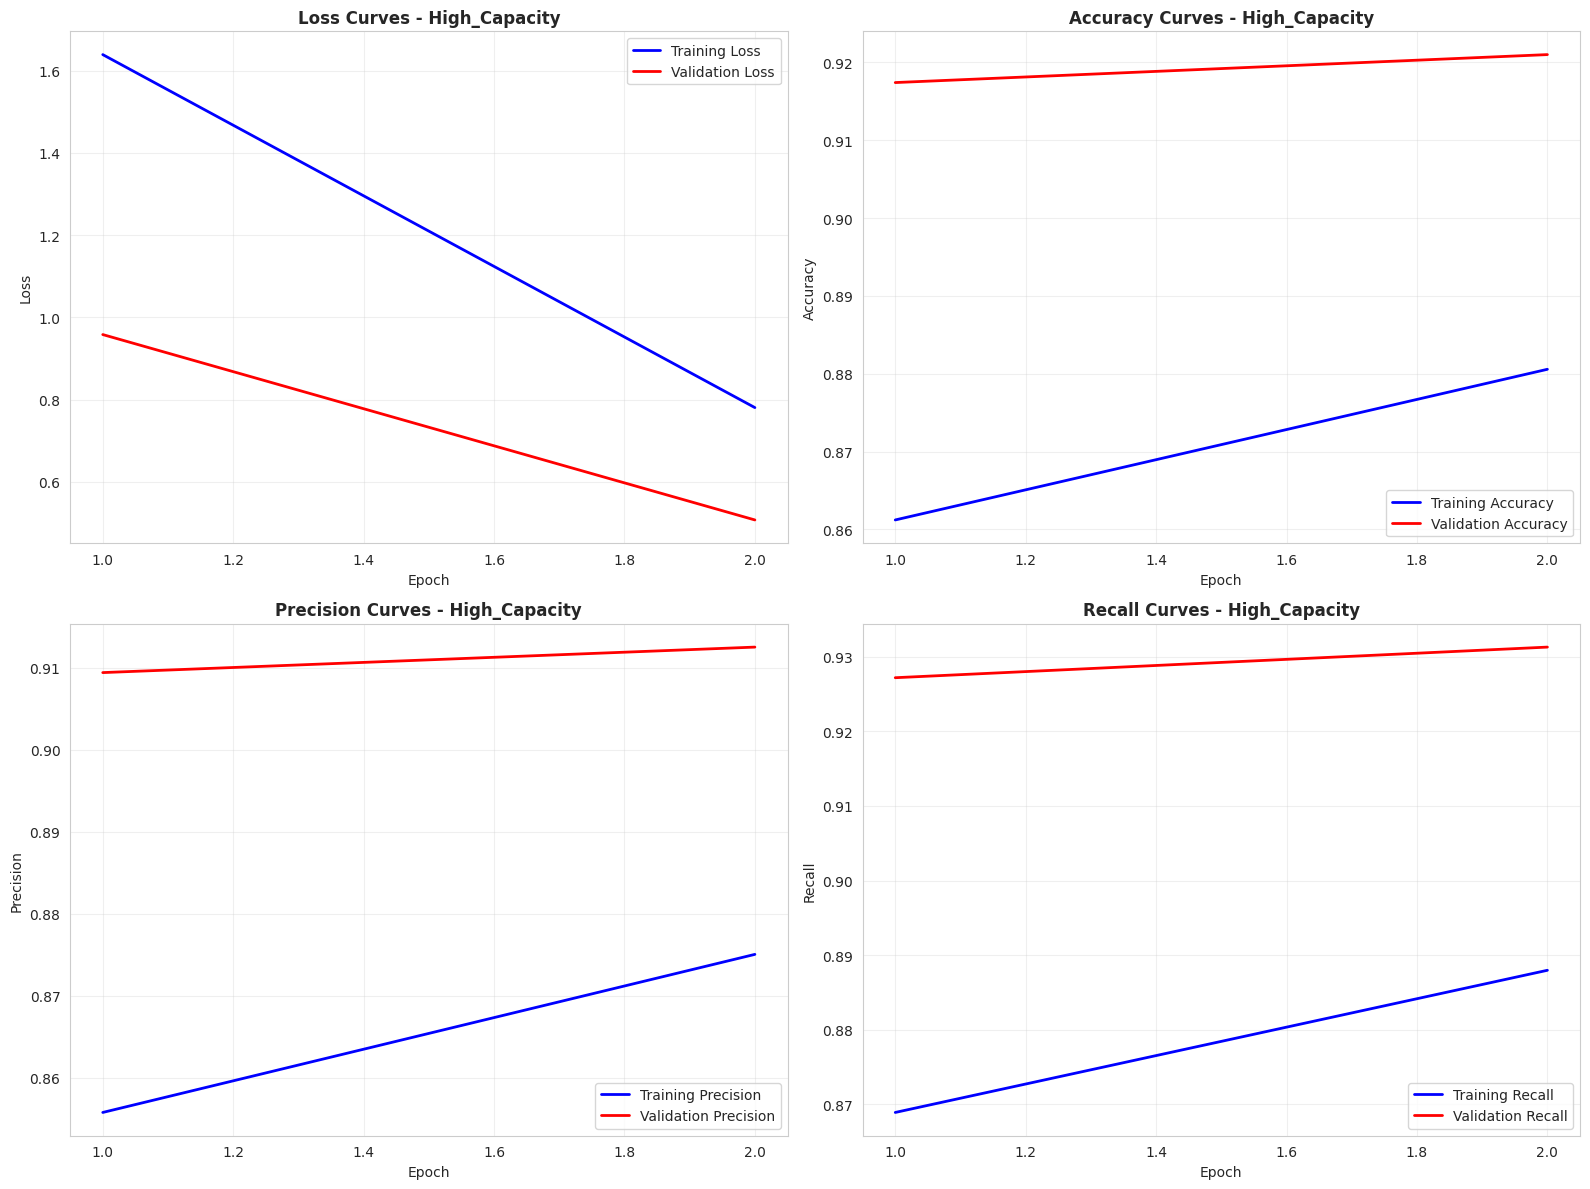


Plotting curves for: Regularized


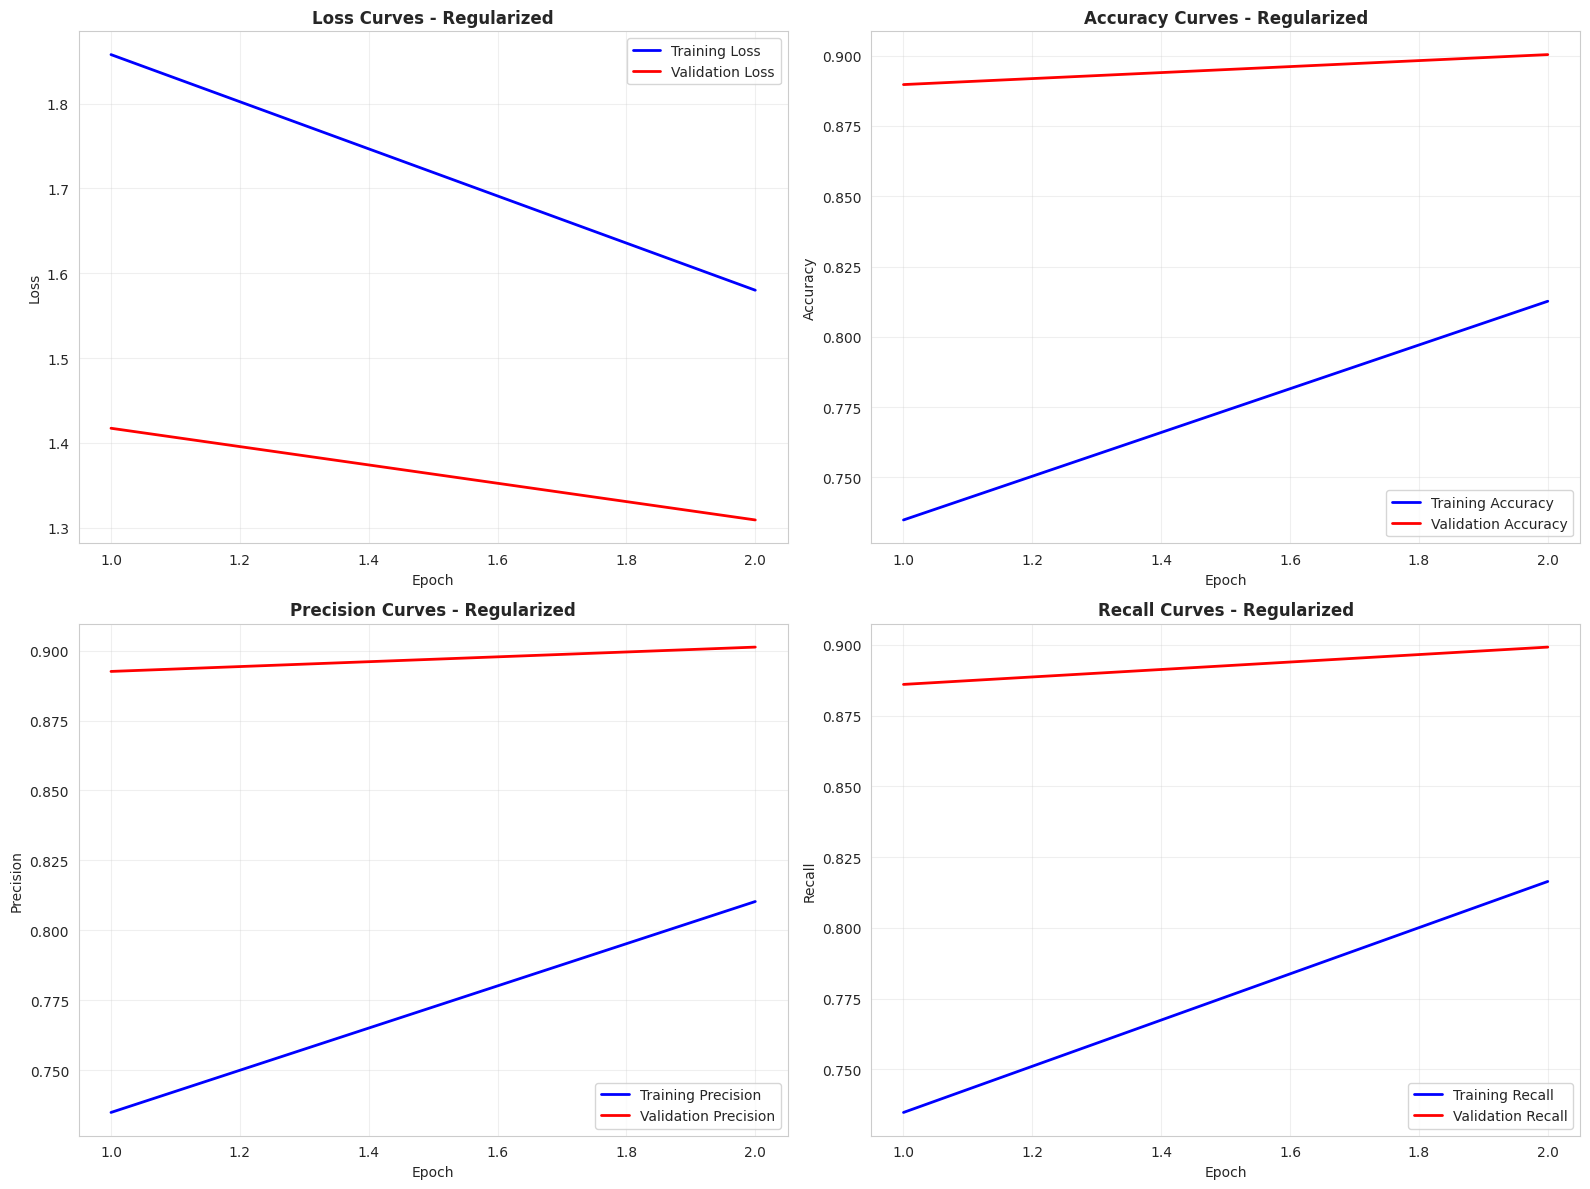

In [30]:
# plot validation curves

def plot_training_history(history_dict, model_name, save=True):
    """
    Plot training & validation curves
    """
    history = history_dict['history']
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    epochs_range = range(1, len(history['loss']) + 1)
    
    # Plot 1: Loss
    axes[0, 0].plot(epochs_range, history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title(f'Loss Curves - {model_name}', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Accuracy
    axes[0, 1].plot(epochs_range, history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs_range, history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title(f'Accuracy Curves - {model_name}', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Precision
    axes[1, 0].plot(epochs_range, history['precision'], 'b-', label='Training Precision', linewidth=2)
    axes[1, 0].plot(epochs_range, history['val_precision'], 'r-', label='Validation Precision', linewidth=2)
    axes[1, 0].set_title(f'Precision Curves - {model_name}', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Recall
    axes[1, 1].plot(epochs_range, history['recall'], 'b-', label='Training Recall', linewidth=2)
    axes[1, 1].plot(epochs_range, history['val_recall'], 'r-', label='Validation Recall', linewidth=2)
    axes[1, 1].set_title(f'Recall Curves - {model_name}', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save:
        plt.savefig(f'/kaggle/working/{model_name}_training_curves.png', dpi=300, bbox_inches='tight')
    
    plt.show()

# plot untuk semua model
for model_name, results in tuning_results.items():
    print(f"\nPlotting curves for: {model_name}")
    plot_training_history(results, model_name, save=True)

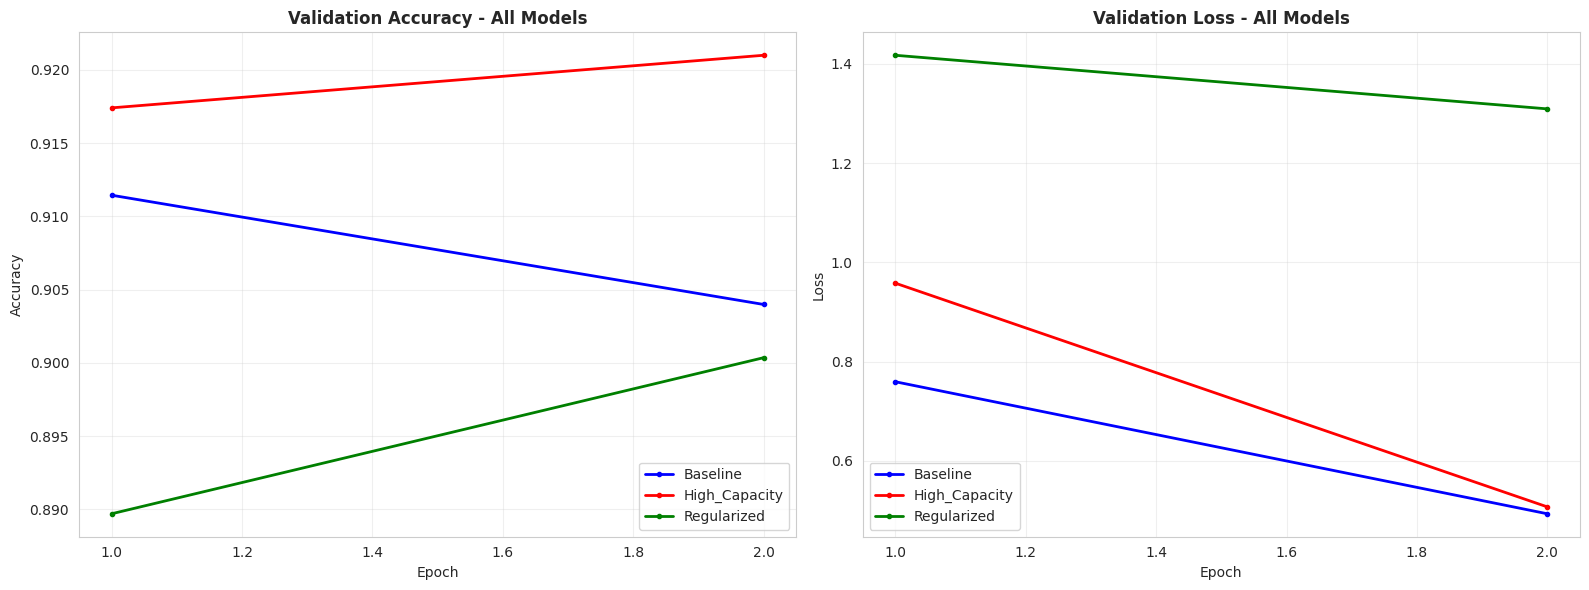

In [31]:
# compare all models in one plot

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['blue', 'red', 'green', 'orange', 'purple']

# validation Accuracy comparison
for i, (model_name, results) in enumerate(tuning_results.items()):
    history = results['history']
    epochs_range = range(1, len(history['val_accuracy']) + 1)
    axes[0].plot(epochs_range, history['val_accuracy'], 
                 color=colors[i % len(colors)], 
                 label=model_name, 
                 linewidth=2, 
                 marker='o', 
                 markersize=3)

axes[0].set_title('Validation Accuracy - All Models', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# validation Loss comparison
for i, (model_name, results) in enumerate(tuning_results.items()):
    history = results['history']
    epochs_range = range(1, len(history['val_loss']) + 1)
    axes[1].plot(epochs_range, history['val_loss'], 
                 color=colors[i % len(colors)], 
                 label=model_name, 
                 linewidth=2, 
                 marker='o', 
                 markersize=3)

axes[1].set_title('Validation Loss - All Models', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

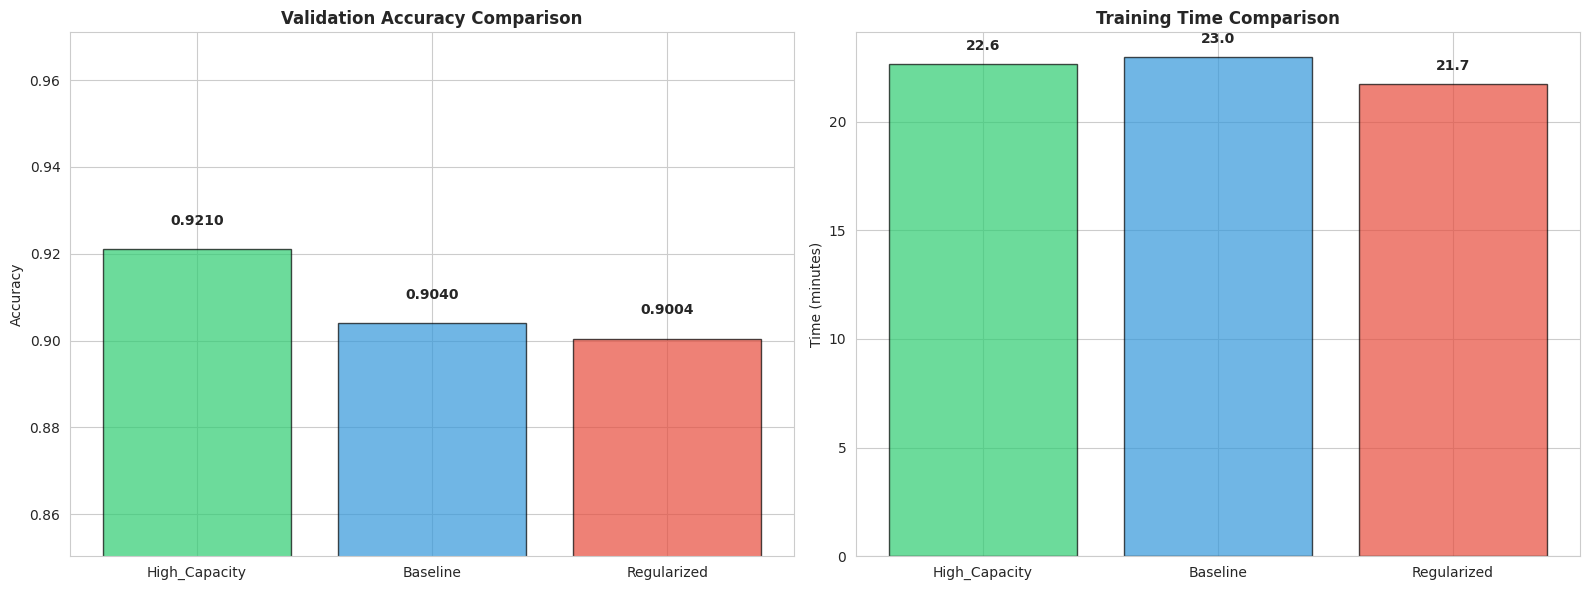

In [32]:
# bar chart comparison

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# accuracy comparison
model_names = comparison_df['Model'].tolist()
accuracies = comparison_df['Val Accuracy'].tolist()

axes[0].bar(model_names, accuracies, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Validation Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([min(accuracies) - 0.05, max(accuracies) + 0.05])

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

# training time comparison
train_times = comparison_df['Training Time (min)'].tolist()

axes[1].bar(model_names, train_times, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Time (minutes)')

for i, v in enumerate(train_times):
    axes[1].text(i, v + 0.5, f'{v:.1f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/models_bar_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# training results

import os
from pathlib import Path
import datetime

output_path = '/kaggle/working/'

# Define checkpoint directory
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
Path(CHECKPOINT_DIR).mkdir(exist_ok=True)

print("\n" + "="*70)
print("SAVING ALL TRAINING RESULTS")
print("="*70)
print(f"Output path: {output_path}")
print(f"Checkpoint dir: {CHECKPOINT_DIR}")

# 1. Save best model
best_model = tuning_results[best_model_name]['model']
best_model.save(f'{output_path}best_model_{best_model_name}.h5')
print(f"✓ Saved best model: best_model_{best_model_name}.h5")

# Also save with generic name for easier loading
best_model.save(f'{output_path}best_model.h5')
print(f"✓ Saved best model: best_model.h5")

# 2. Save all training histories
with open(f'{output_path}all_training_histories.pkl', 'wb') as f:
    # Save only serializable data (exclude model objects)
    histories_to_save = {}
    for name, results in tuning_results.items():
        histories_to_save[name] = {
            'config': results['config'],
            'history': results['history'],
            'val_loss': results['val_loss'],
            'val_accuracy': results['val_accuracy'],
            'val_precision': results['val_precision'],
            'val_recall': results['val_recall'],
            'val_auc': results['val_auc'],
            'training_time': results['training_time']
        }
    pickle.dump(histories_to_save, f)
print(f"✓ Saved all training histories: all_training_histories.pkl")

# 3. Save best model info
best_model_info = {
    'best_model_name': best_model_name,
    'best_config': best_model_results['config'],
    'val_loss': best_model_results['val_loss'],
    'val_accuracy': best_model_results['val_accuracy'],
    'val_precision': best_model_results['val_precision'],
    'val_recall': best_model_results['val_recall'],
    'val_auc': best_model_results['val_auc'],
    'training_time': best_model_results['training_time']
}

with open(f'{output_path}best_model_info.pkl', 'wb') as f:
    pickle.dump(best_model_info, f)
print(f"✓ Saved best model info: best_model_info.pkl")

# 4. Save comparison dataframe as CSV
comparison_df.to_csv(f'{output_path}models_comparison.csv', index=False)
print(f"✓ Saved models comparison: models_comparison.csv")

# 5. Save modeling metadata
modeling_metadata = {
    'random_state': RANDOM_STATE,
    'target_size': TARGET_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'patience': PATIENCE,
    'vgg_version': 'VGG16',
    'total_models_trained': len(tuning_results),
    'best_model_name': best_model_name,
    'training_configs': tuning_configs,
    'class_indices': train_generator.class_indices,
    'augmentation_config': {
        'rotation_range': 20,
        'width_shift_range': 0.2,
        'height_shift_range': 0.2,
        'shear_range': 0.2,
        'zoom_range': 0.2,
        'horizontal_flip': True
    },
    'timestamp': datetime.datetime.now().isoformat()
}

with open(f'{output_path}modeling_metadata.pkl', 'wb') as f:
    pickle.dump(modeling_metadata, f)
print(f"✓ Saved modeling metadata: modeling_metadata.pkl")

# 6. Save all individual models
print("\nSaving individual models...")
for model_name, results in tuning_results.items():
    model = results['model']
    
    # Save to main output directory
    model.save(f'{output_path}model_{model_name}.h5')
    print(f"  ✓ Saved: model_{model_name}.h5")
    
    # Also save to checkpoint directory
    model.save(f'{CHECKPOINT_DIR}/model_{model_name}.h5')
    
    # Save individual history to checkpoint
    with open(f'{CHECKPOINT_DIR}/history_{model_name}.pkl', 'wb') as f:
        pickle.dump(results['history'], f)
    
    # Save individual results to checkpoint
    results_meta = {
        'config': results['config'],
        'val_loss': results['val_loss'],
        'val_accuracy': results['val_accuracy'],
        'val_precision': results['val_precision'],
        'val_recall': results['val_recall'],
        'val_auc': results['val_auc'],
        'training_time': results['training_time']
    }
    with open(f'{CHECKPOINT_DIR}/results_{model_name}.pkl', 'wb') as f:
        pickle.dump(results_meta, f)

print(f"\n✓ All models saved to checkpoint directory: {CHECKPOINT_DIR}")

# 7. Create summary report (text file)
summary_report = []
summary_report.append("="*70)
summary_report.append("HYPERPARAMETER TUNING SUMMARY REPORT")
summary_report.append("="*70)
summary_report.append(f"\nTraining Date: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
summary_report.append(f"Random State: {RANDOM_STATE}")
summary_report.append(f"Epochs: {EPOCHS}")
summary_report.append(f"Patience: {PATIENCE}")
summary_report.append(f"Target Size: {TARGET_SIZE}")
summary_report.append(f"Batch Size: {BATCH_SIZE}")

summary_report.append(f"\n{'='*70}")
summary_report.append("MODELS COMPARISON")
summary_report.append(f"{'='*70}\n")
summary_report.append(comparison_df.to_string(index=False))

summary_report.append(f"\n{'='*70}")
summary_report.append("BEST MODEL")
summary_report.append(f"{'='*70}")
summary_report.append(f"Model Name: {best_model_name}")
summary_report.append(f"Val Accuracy: {best_model_results['val_accuracy']:.4f}")
summary_report.append(f"Val Loss: {best_model_results['val_loss']:.4f}")
summary_report.append(f"Val Precision: {best_model_results['val_precision']:.4f}")
summary_report.append(f"Val Recall: {best_model_results['val_recall']:.4f}")
summary_report.append(f"Val AUC: {best_model_results['val_auc']:.4f}")
summary_report.append(f"Training Time: {best_model_results['training_time']/60:.2f} minutes")

summary_report.append(f"\nConfiguration:")
for key, value in best_model_results['config'].items():
    if key != 'name':
        summary_report.append(f"  {key}: {value}")

summary_report.append(f"\n{'='*70}")
summary_report.append("MODEL ARCHITECTURE")
summary_report.append(f"{'='*70}")

# Get model summary as string
from io import StringIO
import sys

# Capture model summary
old_stdout = sys.stdout
sys.stdout = mystdout = StringIO()
best_model.summary()
sys.stdout = old_stdout
model_summary_str = mystdout.getvalue()

summary_report.append(model_summary_str)

# Save report
report_text = '\n'.join(summary_report)
with open(f'{output_path}training_summary_report.txt', 'w') as f:
    f.write(report_text)
print(f"\n✓ Saved training summary report: training_summary_report.txt")

# 8. Display final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"\nBest Model: {best_model_name}")
print(f"Val Accuracy: {best_model_results['val_accuracy']:.4f}")
print(f"\nConfiguration:")
for key, value in best_model_results['config'].items():
    if key != 'name':
        print(f"  {key}: {value}")

print("\n" + "="*70)
print("OUTPUT FILES SAVED")
print("="*70)
print(f"\nMain directory: {output_path}")
print("\nEssential files:")
print(f"  1. best_model.h5")
print(f"  2. best_model_{best_model_name}.h5")
print(f"  3. best_model_info.pkl")
print(f"  4. models_comparison.csv")
print(f"  5. all_training_histories.pkl")
print(f"  6. modeling_metadata.pkl")
print(f"  7. training_summary_report.txt")

print("\nIndividual models:")
for i, model_name in enumerate(tuning_results.keys(), 1):
    print(f"  {i}. model_{model_name}.h5")

print(f"\nCheckpoint directory: {CHECKPOINT_DIR}")
checkpoint_files = os.listdir(CHECKPOINT_DIR) if os.path.exists(CHECKPOINT_DIR) else []
if checkpoint_files:
    print(f"Files in checkpoints: {len(checkpoint_files)}")
    for file in sorted(checkpoint_files):
        print(f"  - {file}")

print("\n" + "="*70)
print("DATA MODELLING COMPLETED SUCCESSFULLY!")
print("="*70)
print("\n✓ All models trained and saved")
print("✓ Ready for Evaluation phase")
print("\nNext steps:")
print("  1. Create new notebook: '4. Evaluation'")
print("  2. Add this notebook's output as dataset input")
print("  3. Load best_model.h5 and evaluate on test set")

# 9. Optional: Create a backup zip
print("\n" + "="*70)
print("CREATING BACKUP ZIP")
print("="*70)

import zipfile

# Create zip file
zip_filename = f'{output_path}data_modelling_backup.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    # Add all .h5 files from main directory
    for model_name in tuning_results.keys():
        file_path = f'{output_path}model_{model_name}.h5'
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
    
    # Add best model
    best_model_files = [
        f'{output_path}best_model.h5',
        f'{output_path}best_model_{best_model_name}.h5'
    ]
    for file_path in best_model_files:
        if os.path.exists(file_path):
            zipf.write(file_path, os.path.basename(file_path))
    
    # Add pkl files
    pkl_files = [
        'best_model_info.pkl',
        'all_training_histories.pkl',
        'modeling_metadata.pkl'
    ]
    for pkl_file in pkl_files:
        file_path = f'{output_path}{pkl_file}'
        if os.path.exists(file_path):
            zipf.write(file_path, pkl_file)
    
    # Add csv and txt
    other_files = ['models_comparison.csv', 'training_summary_report.txt']
    for file in other_files:
        file_path = f'{output_path}{file}'
        if os.path.exists(file_path):
            zipf.write(file_path, file)
    
    # Add checkpoint files
    if os.path.exists(CHECKPOINT_DIR):
        for root, dirs, files in os.walk(CHECKPOINT_DIR):
            for file in files:
                file_path = os.path.join(root, file)
                arcname = os.path.join('checkpoints', file)
                zipf.write(file_path, arcname)

print(f"✓ Backup created: {zip_filename}")
if os.path.exists(zip_filename):
    print(f"  Size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB")

print("\n" + "="*70)
print("ALL DONE! 🎉")
print("="*70)


SAVING ALL TRAINING RESULTS
Output path: /kaggle/working/
Checkpoint dir: /kaggle/working/checkpoints
✓ Saved best model: best_model_High_Capacity.h5
✓ Saved best model: best_model.h5
✓ Saved all training histories: all_training_histories.pkl
✓ Saved best model info: best_model_info.pkl
✓ Saved models comparison: models_comparison.csv
✓ Saved modeling metadata: modeling_metadata.pkl

Saving individual models...
  ✓ Saved: model_Baseline.h5
  ✓ Saved: model_High_Capacity.h5
  ✓ Saved: model_Regularized.h5

✓ All models saved to checkpoint directory: /kaggle/working/checkpoints


Model: "VGG16_Gender_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 1024)           │     8,389,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 1024)           │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,471,813 (158.20 MB)

 Trainable params: 8,918,017 (34.02 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

 Optimizer params: 17,836,036 (68.04 MB)


✓ Saved training summary report: training_summary_report.txt

FINAL SUMMARY

Best Model: High_Capacity
Val Accuracy: 0.9210

Configuration:
  vgg_version: VGG16
  dense_units: 1024
  dropout_rate: 0.3
  learning_rate: 0.0001

OUTPUT FILES SAVED

Main directory: /kaggle/working/

Essential files:
  1. best_model.h5
  2. best_model_High_Capacity.h5
  3. best_model_info.pkl
  4. models_comparison.csv
  5. all_training_histories.pkl
  6. modeling_metadata.pkl
  7. training_summary_report.txt

Individual models:
  1. model_Baseline.h5
  2. model_High_Capacity.h5
  3. model_Regularized.h5

Checkpoint directory: /kaggle/working/checkpoints
Files in checkpoints: 9
  - history_Baseline.pkl
  - history_High_Capacity.pkl
  - history_Regularized.pkl
  - model_Baseline.h5
  - model_High_Capacity.h5
  - model_Regularized.h5
  - results_Baseline.pkl
  - results_High_Capacity.pkl
  - results_Regularized.pkl

DATA MODELLING COMPLETED SUCCESSFULLY!

✓ All models trained and saved
✓ Ready for Evaluation